## **Predicting Default Risk on Peer-to-Peer Lending Platform**

Name: Vy (Valerie) Le


# **Peer-to-peer (P2P):**
Lending is a method of debt financing that enables individuals to borrow and lend money without the use of an official financial institution as an intermediary. P2P lending removes the middleman from the process, but it also involves more time, effort, and risk than the general route of going through a traditional financial institution. We have information about different loans in the past. We want to use this information to predict the default risk and the returns associated with different types of loans, and recommend a financial decision on which types of loans to invest.

# 1.	Data Pre-processing

Import Libraries

In [ ]:
# Import Libraries
import pandas as pd #for data analysis#
import numpy as np #for data analysis#
import matplotlib.pyplot as plt #for visualization#
import seaborn as sns #for better looking visualization
import scipy.stats as stats
import statsmodels.api as sm #library for statistics analysis#
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.stats.anova import anova_lm
!pip install ISLP
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

Load the data

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set styles for visualization
sns.set(style='whitegrid')

# Load Data
file_path = '/content/drive/MyDrive/BUS 310: Business Analytics III/Group Assignment 2/cleaned_p2p_2007_to_2018Q4.csv'
df = pd.read_csv(file_path)

# Check first few rows
print(df.head())

# Basic Information
df.info()

# Summary Statistics
df.describe()

# Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values[missing_values > 0])

# Check unique values in loan_status (target variable)
print("\nUnique values in 'loan_status':", df['loan_status'].unique())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-8-3960fbf908f9>:10: DtypeWarning: Columns (45,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


         id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  \
0  66624733      18000        18000          18000.0   60 months     19.48   
1  67849662       4225         4225           4225.0   36 months     14.85   
2  67715283      16000        16000          16000.0   36 months     12.88   
3  68341789      24250        24250          24250.0   60 months     24.24   
4  68415473      25000        25000          25000.0   60 months     13.99   

   installment grade sub_grade              emp_title  ... percent_bc_gt_75  \
0       471.70     E        E2       Software Manager  ...             14.3   
1       146.16     C        C5               mechanic  ...              0.0   
2       538.18     C        C2  Owner, Fee Appraiser   ...              0.0   
3       701.01     F        F3        hvac technician  ...             63.6   
4       581.58     C        C4    Executive Assistant  ...              0.0   

  pub_rec_bankruptcies  tax_liens tot_hi_cred_lim total_

# Understand the data

Check and see how loan_status looks like

Unique values in 'loan_status':
 ['Charged Off' 'Current' 'Default' 'Fully Paid' 'In Grace Period'
 'Late (16-30 days)' 'Late (31-120 days)']

Loan Status Counts:
 loan_status
Fully Paid            482595
Current               415476
Charged Off           129187
Late (31-120 days)     10879
In Grace Period         4227
Late (16-30 days)       2104
Default                   21
Name: count, dtype: int64


<ipython-input-9-998559411a8b>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


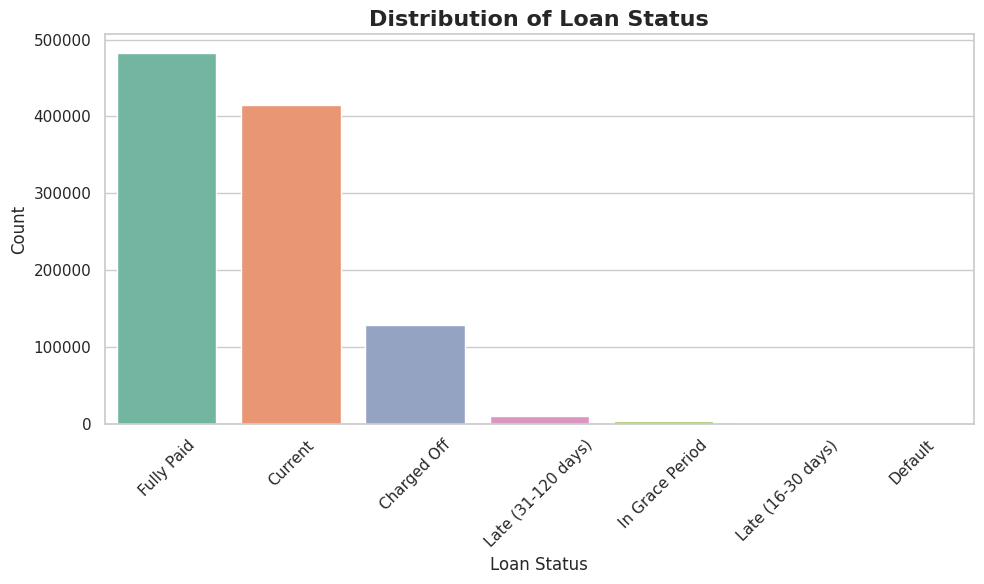

In [ ]:
# Focus on loan_status
print("Unique values in 'loan_status':\n", df['loan_status'].unique())

# Check how often each status appears
loan_status_counts = df['loan_status'].value_counts()
print("\nLoan Status Counts:\n", loan_status_counts)

# Plot the loan_status distribution with an aesthetic color palette
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.countplot(
    x='loan_status',
    data=df,
    order=loan_status_counts.index,
    palette="Set2"
)
plt.title('Distribution of Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Keep only observations that are “Charged-off”, “Default”, and “Fully Paid”. Check how many observations left.

Unique values after filtering:
 ['Charged Off' 'Default' 'Fully Paid']

Number of observations left: 611803


<ipython-input-10-b671bd496dc0>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


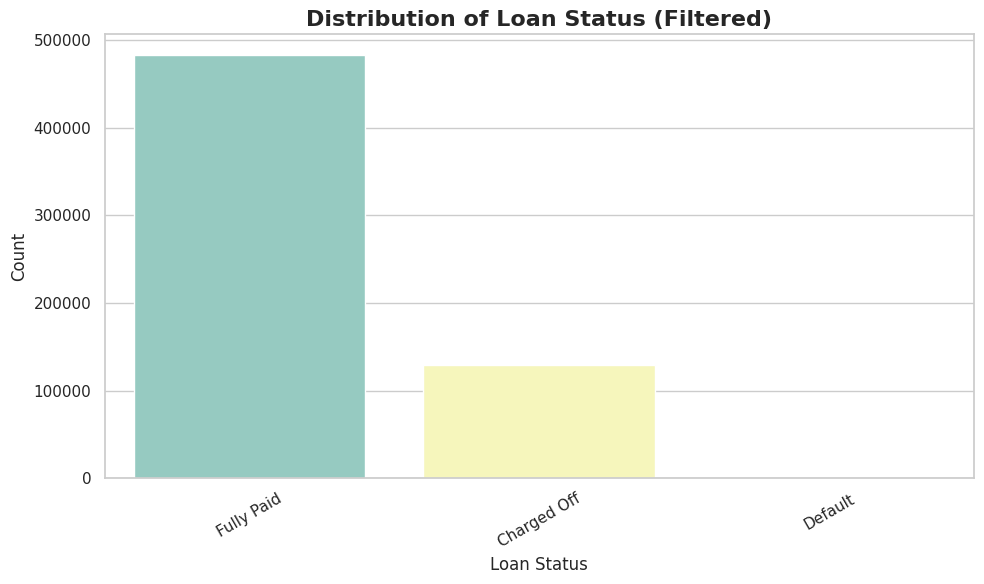

In [ ]:
# Keep only "Charged Off", "Default", and "Fully Paid" loans
keep_status = ['Charged Off', 'Default', 'Fully Paid']
df = df[df['loan_status'].isin(keep_status)]

# Check again
print("Unique values after filtering:\n", df['loan_status'].unique())

# How many observations are left?
print("\nNumber of observations left:", df.shape[0])

# Updated distribution with aesthetic styling
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.countplot(
    x='loan_status',
    data=df,
    order=df['loan_status'].value_counts().index,
    palette="Set3"
)
plt.title('Distribution of Loan Status (Filtered)', fontsize=16, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Make a dummy variable that equals 1 if the loan_status is Charged-off and default; equals 0 if it is fully paid.

   loan_status  loan_default
0  Charged Off             1
1  Charged Off             1
2  Charged Off             1
3  Charged Off             1
4  Charged Off             1

Distribution of loan_default (0 = Fully Paid, 1 = Default/Charged Off):
loan_default
0    482595
1    129208
Name: count, dtype: int64


<ipython-input-11-7eeed3a53e0f>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_default', data=df, palette={"0": "#66c2a5", "1": "#fc8d62"})


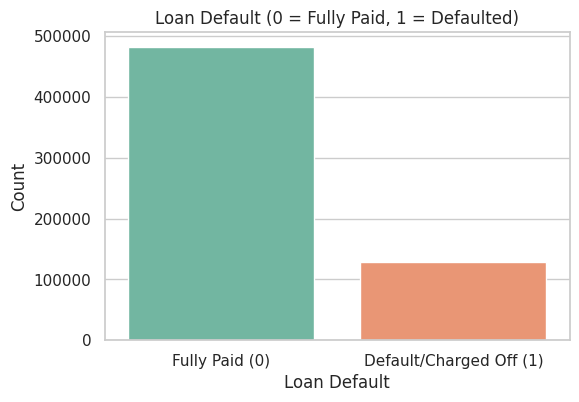

In [ ]:
# Create a new column 'loan_default'
df['loan_default'] = df['loan_status'].apply(lambda x: 1 if x in ['Charged Off', 'Default'] else 0)

# Quick check
print(df[['loan_status', 'loan_default']].head())

# Distribution of new dummy variable
print("\nDistribution of loan_default (0 = Fully Paid, 1 = Default/Charged Off):")
print(df['loan_default'].value_counts())

# Plot it
plt.figure(figsize=(6,4))
sns.countplot(x='loan_default', data=df, palette={"0": "#66c2a5", "1": "#fc8d62"})
plt.title('Loan Default (0 = Fully Paid, 1 = Defaulted)')
plt.xlabel('Loan Default')
plt.ylabel('Count')
plt.xticks([0,1], ['Fully Paid (0)', 'Default/Charged Off (1)'])
plt.show()

In [ ]:
# Calculate overall default rate
default_rate = df['loan_default'].mean()
print(f"Overall Default (Charged-off) Rate: {default_rate:.4f} or {default_rate*100:.2f}%")

Overall Default (Charged-off) Rate: 0.2112 or 21.12%


In [ ]:
# Parse issue_d with specific format
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%y')

# Now check the range of years
print("Earliest year:", df['issue_d'].dt.year.min())
print("Latest year:", df['issue_d'].dt.year.max())
print("Number of years of data:", df['issue_d'].dt.year.max() - df['issue_d'].dt.year.min() + 1)

Earliest year: 2015
Latest year: 2018
Number of years of data: 4


Number of Loans per Year:
issue_year
2015    375546
2016    115072
2017     88346
2018     32839
Name: count, dtype: int64

Default Rate per Year (%):
issue_year
2015    20.19
2016    23.39
2017    23.87
2018    16.46
Name: loan_default, dtype: float64


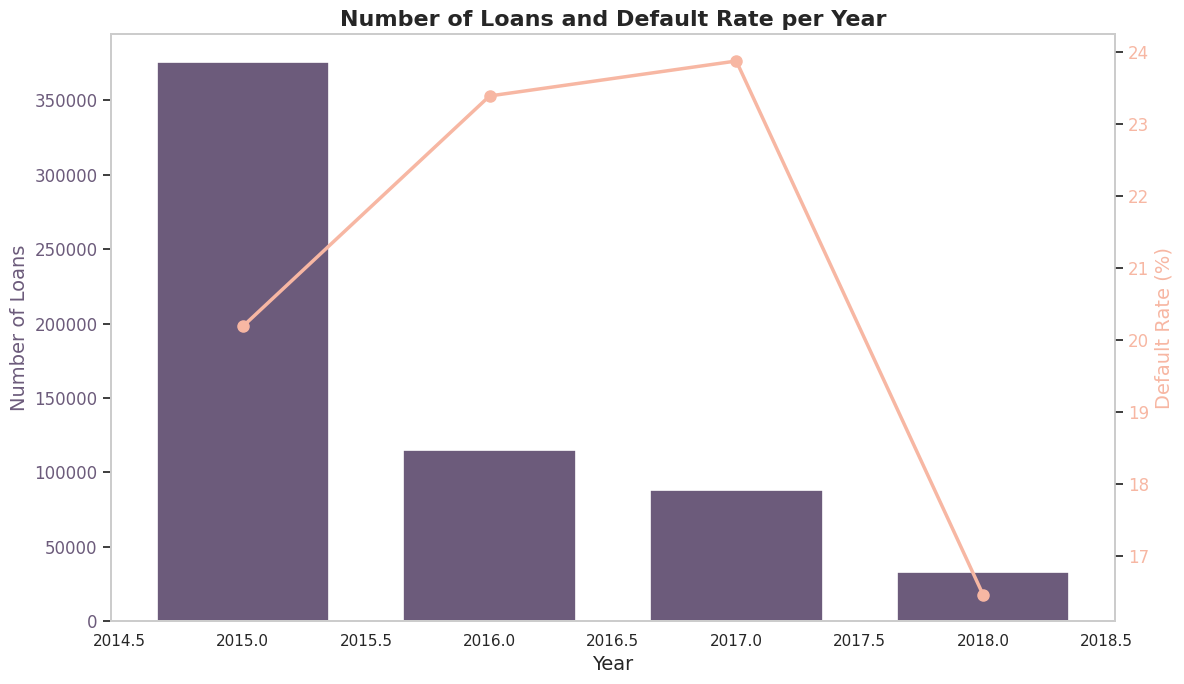

In [ ]:
# Create a new column for the year
df['issue_year'] = df['issue_d'].dt.year

# 1. Number of loans per year
loans_per_year = df['issue_year'].value_counts().sort_index()
print("Number of Loans per Year:")
print(loans_per_year)

# 2. Default rate per year
default_rate_per_year = df.groupby('issue_year')['loan_default'].mean() * 100
print("\nDefault Rate per Year (%):")
print(default_rate_per_year.round(2))

# Plot both
import matplotlib.pyplot as plt

# Create the figure and axes
fig, ax1 = plt.subplots(figsize=(12, 7))

# First Axis: Bar Plot for Number of Loans
ax1.bar(
    loans_per_year.index, loans_per_year.values,
    color='#6c5b7b', width=0.7, edgecolor='white', linewidth=1.2  # Muted purple, white border for bars
)
ax1.set_xlabel('Year', fontsize=14, fontweight='light', family='Arial')
ax1.set_ylabel('Number of Loans', color='#6c5b7b', fontsize=14, fontweight='light', family='Arial')
ax1.tick_params(axis='y', labelcolor='#6c5b7b', labelsize=12)

# Second Axis: Line Plot for Default Rate
ax2 = ax1.twinx()
ax2.plot(
    default_rate_per_year.index, default_rate_per_year.values,
    color='#f7b7a3', marker='o', markersize=8, linewidth=2.5  # Soft peach color, larger markers
)
ax2.set_ylabel('Default Rate (%)', color='#f7b7a3', fontsize=14, fontweight='light', family='Arial')
ax2.tick_params(axis='y', labelcolor='#f7b7a3', labelsize=12)

# Title
plt.title('Number of Loans and Default Rate per Year', fontsize=16, fontweight='bold', family='Arial')

# Remove grid for a clean look
ax1.grid(False)
ax2.grid(False)

# Fine-tuning margins and layout
plt.tight_layout()
plt.show()

**Questions:**
<br>**1. What is the overall Charged-off (default) rate?**

The overall Charged-off (default) rate is approximately 21.12%.

<br>**2. How many years of data in this dataset?**

After keeping only Fully Paid, Charged-Off, and Defaulted loans, the data covers 4 years from 2015 to 2018.

<br>**3. How many loans are there for each year? What about the default rate for each year?**

The dataset contains 375,546 loans issued in 2015, 115,072 loans in 2016, 88,346 loans in 2017, and 32,839 loans in 2018. As shown, the number of loans issued decreased each year from 2015 to 2018.

When examining the default rates, we find that the default rate was approximately 20.19% in 2015, increased to 23.39% in 2016, and peaked at 23.87% in 2017. In 2018, the default rate dropped to 16.46%. This trend suggests that loans issued in 2016 and 2017 were slightly riskier compared to those in 2015 and 2018.

# 2. Exploratory Data Analysis

# 2.1. Exploring important variables

Creating New Categorical Variables and Analyze the default rate and average interest rate across different income categories using bar charts

   annual_inc     Income_cat    dti DTI_cat  fico_range_high FICO_cat
0    150000.0    High Income   9.39    Good              669     Fair
1     35000.0  Medium Income  15.22    Good              729     Good
2     65000.0  Medium Income  18.96    Good              679     Good
3     75000.0  Medium Income  20.84    Good              664     Fair
4     79000.0  Medium Income  34.53    Fair              734     Good

Income Category Analysis:
      Income_cat  default_rate  avg_interest_rate
1     Low Income      0.257411          14.697527
2  Medium Income      0.227485          13.044449
0    High Income      0.176315          11.963406


<ipython-input-17-2cb526ed11a1>:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Income_cat', y='default_rate', data=income_analysis, ax=ax1, palette='crest', order=income_analysis['Income_cat'])


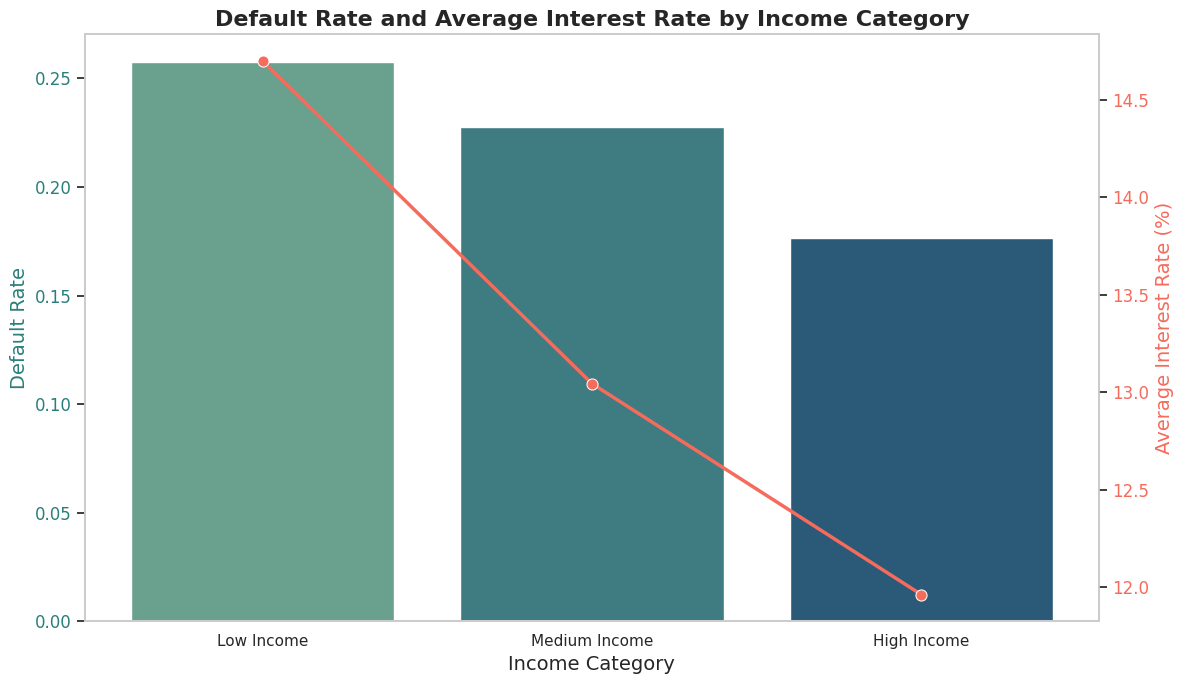

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create Income_cat
def income_category(income):
    if income <= 20000:
        return 'Low Income'
    elif income <= 80000:
        return 'Medium Income'
    else:
        return 'High Income'

df['Income_cat'] = df['annual_inc'].apply(income_category)

# 2. Create DTI_cat
def dti_category(dti):
    if dti <= 28:
        return 'Good'
    elif dti <= 40:
        return 'Fair'
    else:
        return 'Bad'

df['DTI_cat'] = df['dti'].apply(dti_category)

# 3. Create FICO_cat
def fico_category(fico):
    if fico < 580:
        return 'Poor'
    elif fico <= 669:
        return 'Fair'
    elif fico <= 739:
        return 'Good'
    else:
        return 'Very Good'

df['FICO_cat'] = df['fico_range_high'].apply(fico_category)

# Quick Check
print(df[['annual_inc', 'Income_cat', 'dti', 'DTI_cat', 'fico_range_high', 'FICO_cat']].head())

# 4. Analyze default rate and average interest rate by Income_cat
income_analysis = df.groupby('Income_cat').agg(
    default_rate=('loan_default', 'mean'),
    avg_interest_rate=('int_rate', 'mean')
).reset_index()

# Sort by default_rate descending
income_analysis = income_analysis.sort_values('default_rate', ascending=False)

# Display the table
print("\nIncome Category Analysis:")
print(income_analysis)

# 5. Make the bar chart with aesthetic improvements
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot Default Rate with a new color (teal)
sns.barplot(x='Income_cat', y='default_rate', data=income_analysis, ax=ax1, palette='crest', order=income_analysis['Income_cat'])
ax1.set_ylabel('Default Rate', color='#2a7f7b', fontsize=14)
ax1.tick_params(axis='y', labelcolor='#2a7f7b', labelsize=12)
ax1.set_xlabel('Income Category', fontsize=14)

# Create second y-axis
ax2 = ax1.twinx()

# Plot Average Interest Rate with a soft complementary color (coral)
sns.lineplot(x='Income_cat', y='avg_interest_rate', data=income_analysis, ax=ax2, color='#f56b5c', marker='o', linewidth=2.5, markersize=8)
ax2.set_ylabel('Average Interest Rate (%)', color='#f56b5c', fontsize=14)
ax2.tick_params(axis='y', labelcolor='#f56b5c', labelsize=12)

# Title with improved font style
plt.title('Default Rate and Average Interest Rate by Income Category', fontsize=16, fontweight='bold', family='Arial')

# Remove the grid for a cleaner look
ax1.grid(False)
ax2.grid(False)

# Layout adjustments for a cleaner presentation
plt.tight_layout()

# Show the plot
plt.show()

4 similar charts for DTI ratio category, FICO score category, home ownership, and loan purpose

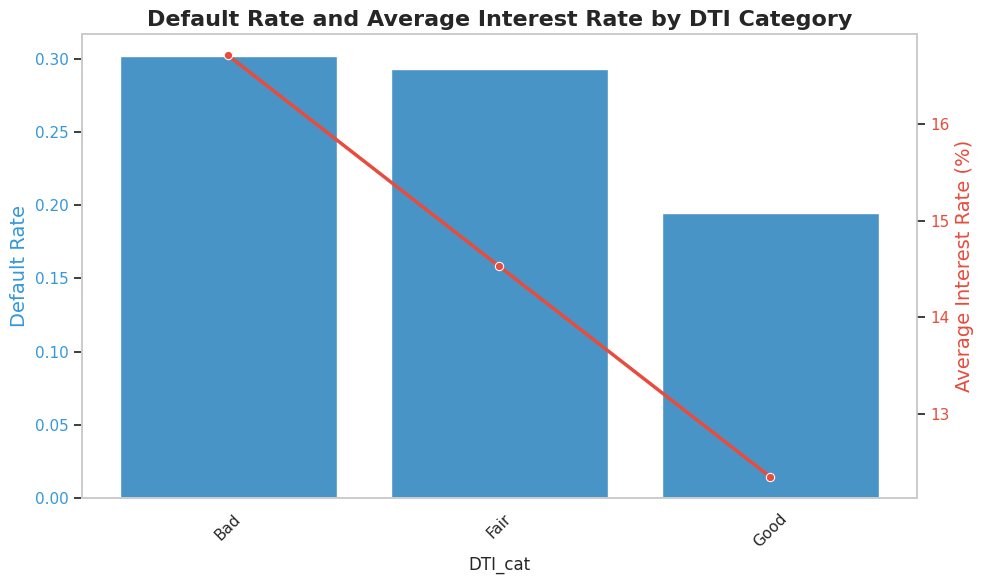

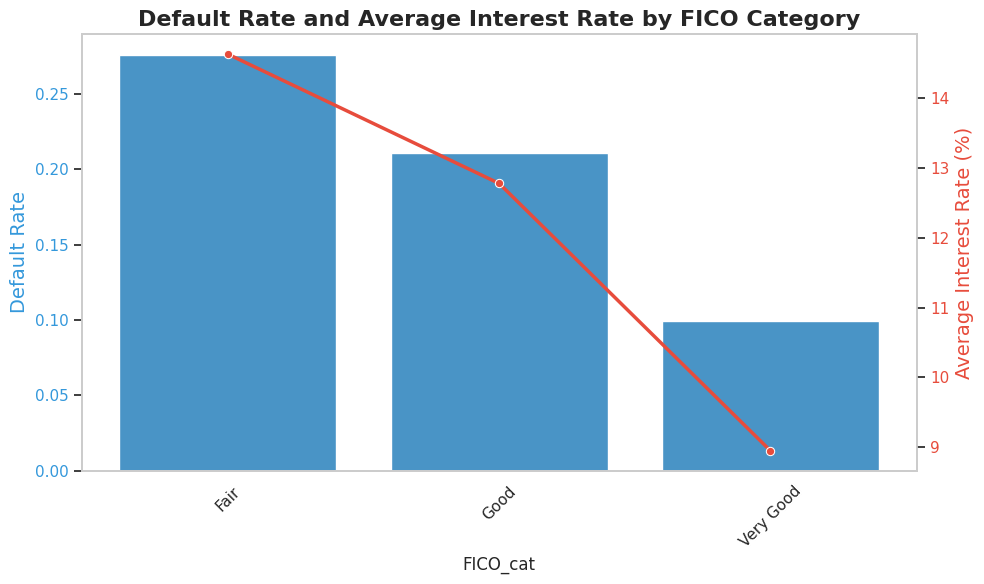

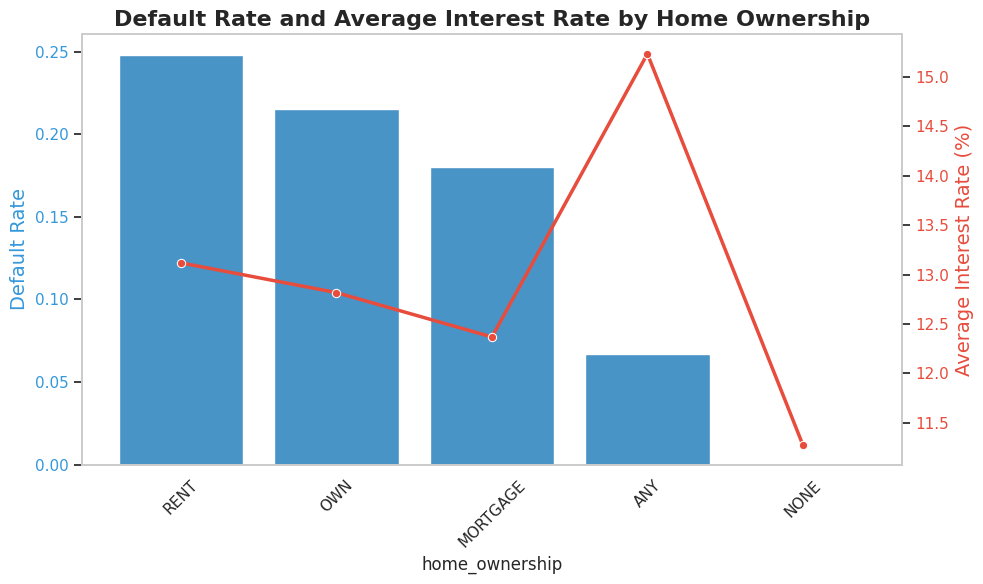

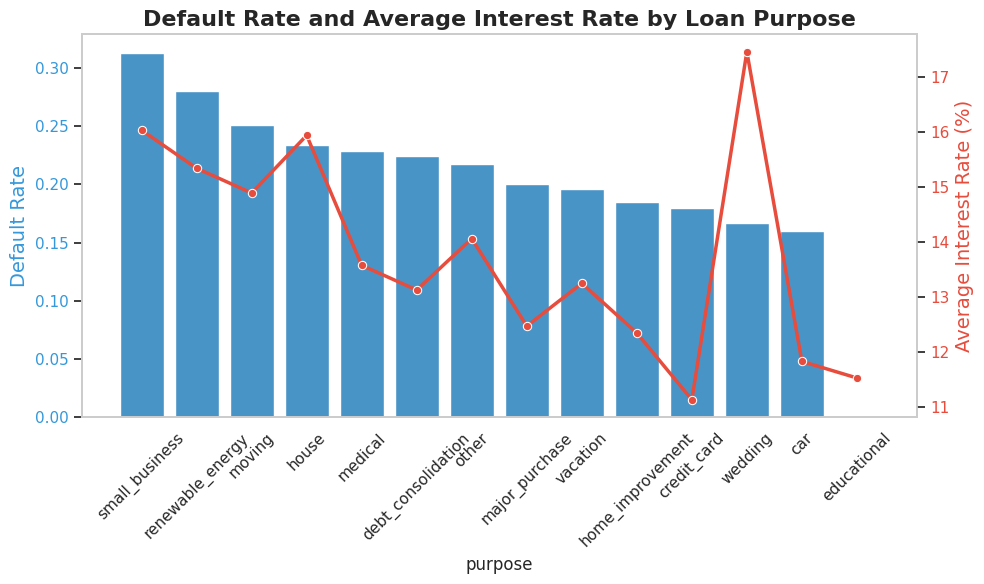

In [ ]:
# Helper function to create bar + line chart with updated colors and no grid
def plot_default_interest(data, category_col, title):
    # Group and calculate
    grouped = data.groupby(category_col).agg(
        default_rate=('loan_default', 'mean'),
        avg_interest_rate=('int_rate', 'mean')
    ).reset_index()

    # Sort by default_rate descending
    grouped = grouped.sort_values('default_rate', ascending=False)

    # Plot
    fig, ax1 = plt.subplots(figsize=(10,6))

    # Bar plot for Default Rate with clean blue color
    sns.barplot(x=category_col, y='default_rate', data=grouped, ax=ax1, color='#3498DB', order=grouped[category_col])
    ax1.set_ylabel('Default Rate', color='#3498DB', fontsize=14)
    ax1.tick_params(axis='y', labelcolor='#3498DB')
    plt.xticks(rotation=45)

    # Second y-axis for Average Interest Rate with soft red color
    ax2 = ax1.twinx()
    sns.lineplot(x=category_col, y='avg_interest_rate', data=grouped, ax=ax2, color='#E74C3C', marker='o', linewidth=2.5)
    ax2.set_ylabel('Average Interest Rate (%)', color='#E74C3C', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='#E74C3C')

    # Title and layout
    plt.title(title, fontsize=16, fontweight='bold', family='Arial')

    # Remove grid
    ax1.grid(False)
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

# 1. DTI ratio category
plot_default_interest(df, 'DTI_cat', 'Default Rate and Average Interest Rate by DTI Category')

# 2. FICO score category
plot_default_interest(df, 'FICO_cat', 'Default Rate and Average Interest Rate by FICO Category')

# 3. Home Ownership
plot_default_interest(df, 'home_ownership', 'Default Rate and Average Interest Rate by Home Ownership')

# 4. Loan Purpose
plot_default_interest(df, 'purpose', 'Default Rate and Average Interest Rate by Loan Purpose')

**Exploring Additional Variable: Term**

<ipython-input-19-ee0d311e1fb4>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=term_stats.index, y=term_stats['loan_default'], ax=axes[0], palette="Set1")
<ipython-input-19-ee0d311e1fb4>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=term_stats.index, y=term_stats['int_rate'], ax=axes[1], palette="Set1")


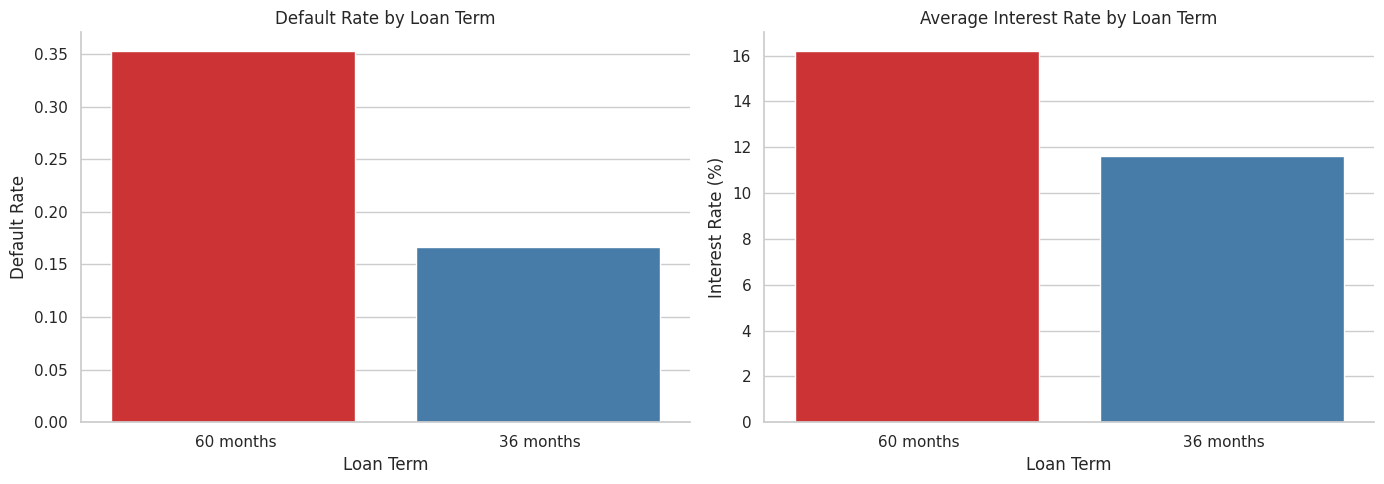

In [ ]:
# Group by term
term_stats = df.groupby('term').agg({
    'loan_default': 'mean',
    'int_rate': 'mean'
}).sort_values(by='loan_default', ascending=False)

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for default rate by loan term
sns.barplot(x=term_stats.index, y=term_stats['loan_default'], ax=axes[0], palette="Set1")
axes[0].set_title('Default Rate by Loan Term')
axes[0].set_ylabel('Default Rate')
axes[0].set_xlabel('Loan Term')

# Bar plot for interest rate by loan term
sns.barplot(x=term_stats.index, y=term_stats['int_rate'], ax=axes[1], palette="Set1")
axes[1].set_title('Average Interest Rate by Loan Term')
axes[1].set_ylabel('Interest Rate (%)')
axes[1].set_xlabel('Loan Term')

sns.despine()
plt.tight_layout()
plt.show()

# 3. Machine Learning Models

# 3.1. OLS Regression

Check the Table 4 of Croux et al. (2020) paper. We try our best to include all the predictors that they use and are available in our data set.

In [ ]:
# Select the features from the table 4
selected_features = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'inq_last_6mths',
    'open_acc', 'revol_util', 'total_acc', 'application_type'
]

# Create the modeling DataFrame
df_model = df[selected_features + ['loan_default']].copy()
df_model.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,fico_range_low,inq_last_6mths,open_acc,revol_util,total_acc,application_type,loan_default
0,18000,60 months,19.48,471.70,E,E2,7 years,RENT,150000.0,Not Verified,debt_consolidation,9.39,0,665,1,18,40.7,27,Individual,1
1,4225,36 months,14.85,146.16,C,C5,5 years,RENT,35000.0,Source Verified,debt_consolidation,15.22,2,725,0,6,24.6,6,Individual,1
2,16000,36 months,12.88,538.18,C,C2,10+ years,MORTGAGE,65000.0,Not Verified,small_business,18.96,0,675,0,7,54.3,20,Individual,1
3,24250,60 months,24.24,701.01,F,F3,4 years,MORTGAGE,75000.0,Not Verified,debt_consolidation,20.84,0,660,0,18,65.3,21,Individual,1
4,25000,60 months,13.99,581.58,C,C4,9 years,MORTGAGE,79000.0,Not Verified,debt_consolidation,34.53,0,730,1,33,18.6,72,Individual,1


Some variables have too many missing values. We will not include those in our regression model.

In [ ]:
# Check for missing values
missing_pct = df_model.isnull().sum().sort_values(ascending=False)
print("Missing value percentage per column:")
print(missing_pct)

Missing value percentage per column:
emp_length             38560
revol_util               326
dti                      218
loan_amnt                  0
application_type           0
total_acc                  0
open_acc                   0
inq_last_6mths             0
fico_range_low             0
delinq_2yrs                0
purpose                    0
term                       0
verification_status        0
annual_inc                 0
home_ownership             0
sub_grade                  0
grade                      0
installment                0
int_rate                   0
loan_default               0
dtype: int64


In [ ]:
# Filling missing dti and revol_util with the mean
df_model['dti'].fillna(df_model['dti'].mean(), inplace=True)
df_model['revol_util'].fillna(df_model['revol_util'].mean(), inplace=True)

<ipython-input-24-82d78b8140f7>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model['dti'].fillna(df_model['dti'].mean(), inplace=True)
<ipython-input-24-82d78b8140f7>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [ ]:
# Fill missing emp_length with the most common (mode) value
mode_emp_length = df_model['emp_length'].mode()[0]
df_model['emp_length'] = df_model['emp_length'].fillna(mode_emp_length)

Conduct necessary predictor processing that we need. Such as creating dummy variables.

In [ ]:
# Get dummies for categorical columns
df_dummies = pd.get_dummies(df_model.drop(columns=['loan_default']), drop_first=True)

# Add back the target variable
df_final = pd.concat([df_dummies, df_model['loan_default']], axis=1)
df_final = df_final.astype(float)

Run an OLS regression using these predictors to examine their relationship with default risk using the whole sample

In [ ]:
# Create the OLS model

# Define X and y
X = df_final.drop(columns=['loan_default'])
y = df_final['loan_default']

# Add constant for intercept
X = sm.add_constant(X)

# Fit OLS model
ols_model = sm.OLS(y, X).fit()

# Show summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           loan_default   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     923.9
Date:                Fri, 11 Apr 2025   Prob (F-statistic):               0.00
Time:                        21:43:18   Log-Likelihood:            -2.8663e+05
No. Observations:              611803   AIC:                         5.734e+05
Df Residuals:                  611726   BIC:                         5.743e+05
Df Model:                          76                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

Predict the probabilities of default status. If the probability of default is greater than 50%, classify it as default otherwise non-default

In [ ]:
# Predict probabilities
y_pred_prob = ols_model.predict(X)

# Classify using 0.5 cutoff
y_pred_class = (y_pred_prob >= 0.5).astype(int)

Make a confusion matrix and calculate the prediction accuracy rate

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Confusion matrix
conf_matrix = confusion_matrix(y, y_pred_class)
print("Confusion Matrix:")
print(conf_matrix)

# Accuracy
accuracy = accuracy_score(y, y_pred_class)
print(f"\nAccuracy: {accuracy:.2%}")

Confusion Matrix:
[[475476   7119]
 [119896   9312]]

Accuracy: 79.24%


# 3.2. Logistic Regression

Using the same variables and run Logistic regression

In [ ]:
# Reuse X and y from before
X_logit = sm.add_constant(X)
y_logit = y

# Fit logistic regression
logit_model = sm.Logit(y_logit, X_logit).fit()

# Show summary
print(logit_model.summary())

         Current function value: 0.462726
         Iterations: 35


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:           loan_default   No. Observations:               611803
Model:                          Logit   Df Residuals:                   611726
Method:                           MLE   Df Model:                           76
Date:                Fri, 11 Apr 2025   Pseudo R-squ.:                  0.1024
Time:                        21:44:09   Log-Likelihood:            -2.8310e+05
converged:                      False   LL-Null:                   -3.1540e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -1.5045      1.060     -1.420      0.156      -3.582       0.573
loan_amnt                           -2.993e-05   2.73e-0

Predict the probabilities of default status. If the probability of default is greater than 50%, classify it as default otherwise non-default

In [ ]:
# Predict default probabilities
y_logit_prob = logit_model.predict(X_logit)

# Classify using 50% cutoff
y_logit_class = (y_logit_prob >= 0.5).astype(int)

Make a confusion matrix and calculate the prediction accuracy rate

In [ ]:
# Confusion matrix
logit_conf_matrix = confusion_matrix(y_logit, y_logit_class)
print("Confusion Matrix:")
print(logit_conf_matrix)

# Accuracy
logit_accuracy = accuracy_score(y_logit, y_logit_class)
print(f"\nAccuracy: {logit_accuracy:.2%}")

Confusion Matrix:
[[472518  10077]
 [116263  12945]]

Accuracy: 79.35%


Split the sample into test and training sample. Do a validation approach to test the prediction accuracy rate

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. Split the data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Create and fit logistic regression model on training data
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# 3. Predict on the test set
y_pred_prob_test = log_reg.predict_proba(X_test)[:, 1]
y_pred_class_test = (y_pred_prob_test > 0.5).astype(int)

# 4. Confusion matrix and accuracy for TEST set
cm_test = confusion_matrix(y_test, y_pred_class_test)
accuracy_test = accuracy_score(y_test, y_pred_class_test)

print("Confusion Matrix (Validation - Test Set):")
print(cm_test)

print(f"\nPrediction Accuracy Rate (Validation - Test Set): {accuracy_test:.4f} or {accuracy_test*100:.2f}%")

Confusion Matrix (Validation - Test Set):
[[141983   2962]
 [ 34770   3826]]

Prediction Accuracy Rate (Validation - Test Set): 0.7944 or 79.44%


# 3.3. Ridge Regression

Run ridge regression with multiple values of λ. Evaluate the prediction accuracy.


In [ ]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler

# Standardize X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Try different alpha (penalty) values
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100,1000,10000]

for alpha in alpha_values:
    print(f"\n--- Ridge with alpha = {alpha} ---")

    ridge = RidgeClassifier(alpha=alpha)
    ridge.fit(X_scaled, y)

    y_ridge_pred = ridge.predict(X_scaled)

    acc = accuracy_score(y, y_ridge_pred)
    cm = confusion_matrix(y, y_ridge_pred)

    print("Accuracy:", f"{acc:.2%}")
    print("Confusion Matrix:")
    print(cm)


--- Ridge with alpha = 0.001 ---
Accuracy: 79.24%
Confusion Matrix:
[[475476   7119]
 [119896   9312]]

--- Ridge with alpha = 0.01 ---
Accuracy: 79.24%
Confusion Matrix:
[[475476   7119]
 [119896   9312]]

--- Ridge with alpha = 0.1 ---
Accuracy: 79.24%
Confusion Matrix:
[[475476   7119]
 [119896   9312]]

--- Ridge with alpha = 1 ---
Accuracy: 79.24%
Confusion Matrix:
[[475476   7119]
 [119897   9311]]

--- Ridge with alpha = 10 ---
Accuracy: 79.24%
Confusion Matrix:
[[475481   7114]
 [119901   9307]]

--- Ridge with alpha = 100 ---
Accuracy: 79.24%
Confusion Matrix:
[[475508   7087]
 [119922   9286]]

--- Ridge with alpha = 1000 ---
Accuracy: 79.23%
Confusion Matrix:
[[475654   6941]
 [120109   9099]]

--- Ridge with alpha = 10000 ---
Accuracy: 79.21%
Confusion Matrix:
[[476120   6475]
 [120731   8477]]


Visualize the effect of λ

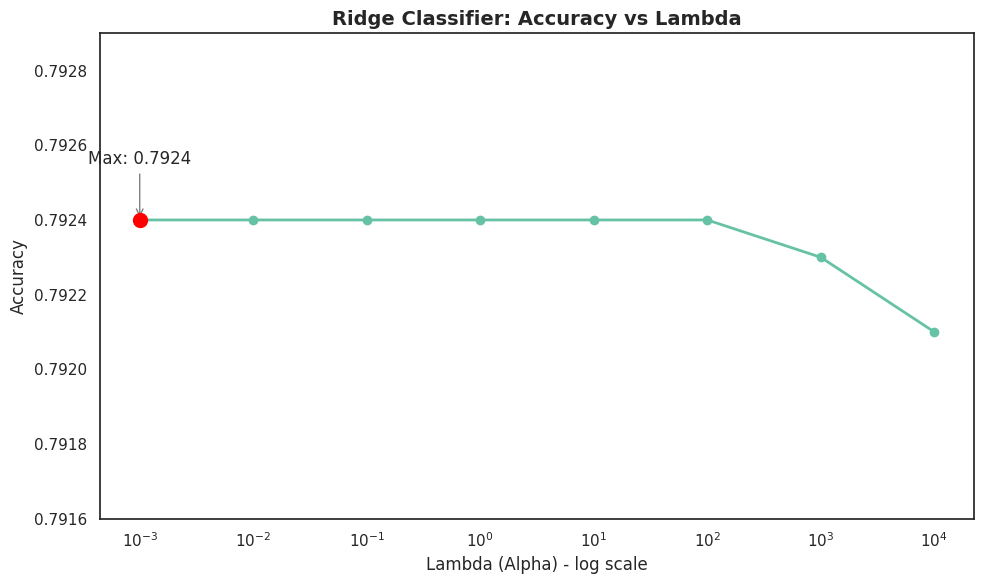

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Alpha (lambda) values and corresponding accuracy from RidgeClassifier
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
accuracy_values = [0.7924, 0.7924, 0.7924, 0.7924, 0.7924, 0.7924, 0.7923, 0.7921]

# Set Seaborn style for aesthetics
sns.set_style("white")  # clean, no grid

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(alpha_values, accuracy_values, marker='o', color='#66c2a5', linewidth=2)

# Set log scale for lambda
plt.xscale('log')
plt.xlabel('Lambda (Alpha) - log scale', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Ridge Classifier: Accuracy vs Lambda', fontsize=14, fontweight='bold')

# Highlight the best accuracy point
max_idx = accuracy_values.index(max(accuracy_values))
best_alpha = alpha_values[max_idx]
best_acc = accuracy_values[max_idx]

plt.scatter(best_alpha, best_acc, color='red', s=100, zorder=5)

# Add annotation with smaller offset to avoid excess white space
plt.annotate(
    f"Max: {best_acc:.4f}",
    xy=(best_alpha, best_acc),
    xytext=(best_alpha, best_acc + 0.00015),
    ha='center',
    arrowprops=dict(arrowstyle='->', color='gray')
)

# Set tight y-axis range to eliminate whitespace
plt.ylim(min(accuracy_values) - 0.0005, max(accuracy_values) + 0.0005)

# Finalize layout and show
plt.tight_layout()
plt.show()

# 3.4	 Lasso Regression

Run ridge regression with multiple values of λ. Evaluate the prediction accuracy

In [ ]:
from sklearn.model_selection import train_test_split

# Take a stratified 20k sample from the full data
X_small, _, y_small, _ = train_test_split(
    X_scaled, y,
    train_size=20000,
    stratify=y,
    random_state=42
)

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

for c in C_values:
    print(f"\n--- Lasso with C = {c} ---")

    lasso = LogisticRegression(
        penalty='l1',
        solver='saga',
        C=c,
        max_iter=300,
        warm_start=True
    )

    lasso.fit(X_small, y_small)
    y_pred = lasso.predict(X_small)

    acc = accuracy_score(y_small, y_pred)
    cm = confusion_matrix(y_small, y_pred)

    print("Accuracy:", f"{acc:.2%}")
    print("Confusion Matrix:")
    print(cm)


--- Lasso with C = 0.001 ---
Accuracy: 78.90%
Confusion Matrix:
[[15771     5]
 [ 4215     9]]

--- Lasso with C = 0.01 ---


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 78.99%
Confusion Matrix:
[[15559   217]
 [ 3985   239]]

--- Lasso with C = 0.1 ---


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 79.34%
Confusion Matrix:
[[15531   245]
 [ 3886   338]]

--- Lasso with C = 1 ---


...

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 79.41%
Confusion Matrix:
[[15520   256]
 [ 3862   362]]

--- Lasso with C = 1000 ---


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy: 79.41%
Confusion Matrix:
[[15520   256]
 [ 3862   362]]

--- Lasso with C = 10000 ---
Accuracy: 79.41%
Confusion Matrix:
[[15520   256]
 [ 3862   362]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Plot Lasso Accuracy vs Lambda

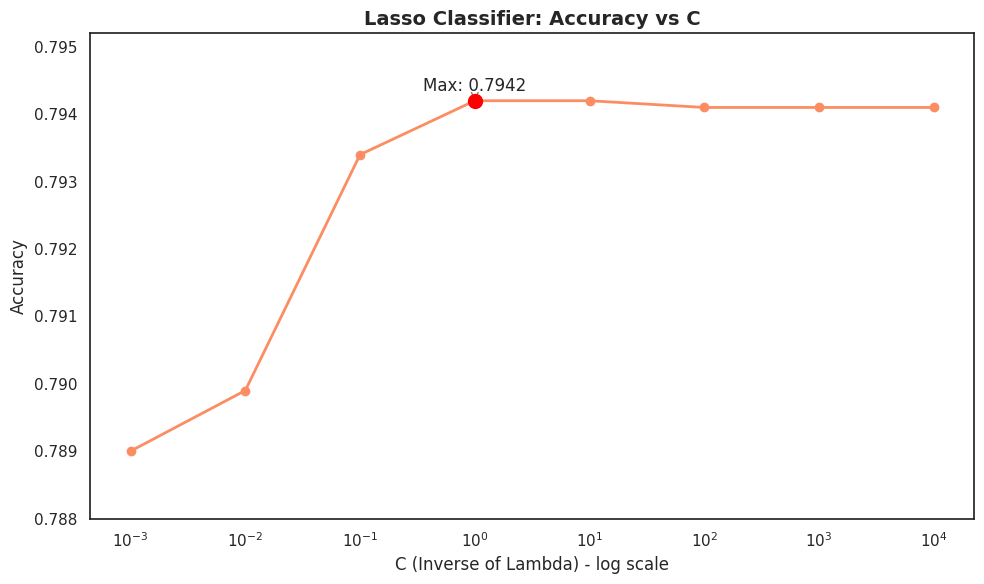

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# C values you tested (inverse of lambda)
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
# Corresponding accuracies from your results
accuracy_values = [0.7890, 0.7899, 0.7934, 0.7942, 0.7942, 0.7941, 0.7941, 0.7941]

# Plot
plt.figure(figsize=(10, 6))
sns.set_style("white")

plt.plot(C_values, accuracy_values, marker='o', color='#fc8d62', linewidth=2)
plt.xscale('log')  # Log scale for C
plt.xlabel('C (Inverse of Lambda) - log scale', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Lasso Classifier: Accuracy vs C', fontsize=14, fontweight='bold')

# Highlight the best accuracy
max_idx = accuracy_values.index(max(accuracy_values))
best_c = C_values[max_idx]
best_acc = accuracy_values[max_idx]

plt.scatter(best_c, best_acc, color='red', s=100, zorder=5)
plt.annotate(
    f"Max: {best_acc:.4f}",
    xy=(best_c, best_acc),
    xytext=(best_c, best_acc + 0.00015),
    ha='center',
    arrowprops=dict(arrowstyle='->', color='gray')
)

# Fix y-axis limits to avoid whitespace
plt.ylim(min(accuracy_values) - 0.001, max(accuracy_values) + 0.001)

plt.tight_layout()
plt.show()

# 4. Be creative

Figure out a model that achieve a higher prediction accuracy rate

**4.1. Random Forest Classifier (ensemble, handles non-linearity)**

To improve prediction performance beyond linear models like Lasso and Ridge, we introduce the Random Forest Classifier — a powerful ensemble learning method that builds multiple decision trees and combines their outputs for more accurate and stable predictions. Unlike linear models, Random Forest can naturally capture non-linear relationships and feature interactions without requiring explicit transformations. It also handles imbalanced datasets and outliers more effectively, making it well-suited for complex real-world data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)

#confusion_table
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("Random Forest Accuracy:", f"{acc:.2%}")

Confusion Matrix:
[[143869   1076]
 [ 36942   1654]]
Random Forest Accuracy: 79.29%


While this model effectively captures non-linear relationships and reduces bias compared to linear models, its accuracy did not surpass the best-performing Lasso model, which achieved 79.42%. This suggests that, in this case, simpler regularized linear models may generalize slightly better to this particular dataset.

**4.2. Gradient Boosting (like XGBoost or HistGradientBoosting)**

To further improve model performance, we explore Gradient Boosting, a highly effective ensemble technique that builds decision trees sequentially, where each new tree focuses on correcting the errors of the previous ones. Unlike Random Forest, which builds trees independently, Gradient Boosting optimizes for performance through gradient-based optimization, allowing it to model complex, non-linear relationships with high accuracy.

In this analysis, we use the HistGradientBoostingClassifier, an efficient implementation of gradient boosting that scales well to large datasets and automatically handles missing values and categorical features. This model is known for its strong performance in structured data problems and is often competitive with more advanced algorithms like XGBoost or LightGBM.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, max_depth=5, random_state=42)
hgb.fit(X_train, y_train)
y_pred = hgb.predict(X_test)

acc = accuracy_score(y_test, y_pred)

#confusion_table
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("HistGradientBoosting Accuracy:", f"{acc:.2%}")

Confusion Matrix:
[[141716   3229]
 [ 34256   4340]]
HistGradientBoosting Accuracy: 79.58%


Compared to previous models, this result outperforms Lasso (79.42%), Ridge (79.24%), Logistic (79.35%), OLS (79.24%), and Random Forest (79.29%), making it the best-performing model in this analysis so far. Despite a slight increase in false positives compared to Lasso, the model correctly identified more true positives (4,340 vs. 362 for Lasso), indicating stronger performance in detecting defaults.

This highlights the strength of gradient boosting in capturing complex patterns and subtle feature interactions. With further hyperparameter tuning (e.g., learning rate, max depth, early stopping), performance may be improved even more.